# Hits calling

This calls hits based on LFC data. Venns
Kexin Dong

Dec 12, 2025

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import seaborn as sns
import warnings
import os 
import functools
import upsetplot
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
import re
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   
mpl.rcParams['ps.fonttype'] = 42 
mpl.rcParams['text.usetex'] = False
from matplotlib_venn import venn2
from sklearn.decomposition import PCA

In [2]:
LIB = pd.read_csv('FINAL_focused_library_PAM.csv', index_col=0)
LIB_OG = pd.read_csv('MBESv2_CORRECTED_PAM.csv', index_col=0)

In [3]:
LFC_ABE = pd.read_csv('ABE_LFC_FDR_df.csv')
LFC_CBE = pd.read_csv('CBE_LFC_FDR_df.csv')
LFC_ABE_OG = pd.read_csv('ABE_LFC_FDR_df_og.csv')
LFC_CBE_OG = pd.read_csv('CBE_LFC_FDR_df_og.csv')
LFC_ABE_VS_BC = pd.read_csv('ABE_LFC_FDR_df_vs_bc.csv')
LFC_CBE_VS_BC = pd.read_csv('CBE_LFC_FDR_df_vs_bc.csv')

# Compare hits with FDR Fishers and FDR stouffers

I am trying to plot Venns that show the intersection of hits that we can call from Fisher's FDR and Stouffer's FDR with the cutoff of FDR = 0.1 (further filter with the input read counts of n = 100); also further filter CBE to CBE NGG guides only; 

Then further filter that out with editing efficiency ≥ 20%.

## For the traditional FDR calculation

In [4]:
print(list(LFC_CBE.columns))

['gRNA_id', 'Gene', 'bm1', 'bm2', 'bm3', 'bm4', 'bm5', 'LFC_avg_bm', 'LFC_median_bm', 'Input_median', 'd15-rep1', 'd15-rep2', 'd15-rep3', 'd15-rep4', 'd15-rep5', 'LFC_avg_d15', 'LFC_median_d15', 'd5-rep1', 'd5-rep2', 'd5-rep3', 'd5-rep4', 'd5-rep5', 'LFC_avg_d5', 'LFC_median_d5', 'input-rep1', 'input-rep2', 'input-rep3', 'input-rep4', 'input-rep5', 'LFC_avg_input', 'LFC_median_input', 'lib', 'LFC_avg_lib', 'LFC_median_lib', 'men1', 'men2', 'men3', 'men4', 'men5', 'LFC_avg_men', 'LFC_median_men', 'spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5', 'LFC_avg_spleen', 'LFC_median_spleen', 'sensor_reads', 'corr_perc', 'target_base_edit_perc', 'byproduct_INDEL_perc', 'byproduct_sub_perc', 'gene_name_m_corrected', 'gene_name_h', 'HGVSp_m', 'HGVSp_h', 'classification', 'classification_m', 'p_high_unadjusted_d5_fishers', 'p_low_unadjusted_d5_fishers', 'FDR_high_d5_fishers', 'FDR_low_d5_fishers', 'p_high_unadjusted_d5_stouffers', 'p_low_unadjusted_d5_stouffers', 'FDR_high_d5_stouffers', 'FDR_

In [5]:
print(list(LFC_CBE_OG.columns))

['gRNA_id', 'Gene', 'spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5', 'spleen6', 'spleen7', 'spleen8', 'spleen9', 'LFC_avg_spleen', 'LFC_median_spleen', 'Input_median', 'bonemarrow1', 'bonemarrow2', 'bonemarrow3', 'bonemarrow4', 'bonemarrow5', 'bonemarrow6', 'bonemarrow7', 'bonemarrow8', 'bonemarrow9', 'bonemarrow10', 'LFC_avg_bonemarrow', 'LFC_median_bonemarrow', 'meninges1', 'meninges2', 'meninges3', 'meninges4', 'meninges5', 'meninges6', 'meninges7', 'meninges8', 'meninges9', 'meninges10', 'LFC_avg_meninges', 'LFC_median_meninges', 'd5_rep1', 'd5_rep2', 'd5_rep3', 'LFC_avg_d5', 'LFC_median_d5', 'd15_rep1', 'd15_rep2', 'd15_rep3', 'LFC_avg_d15', 'LFC_median_d15', 'plasmidlib', 'LFC_avg_plasmid_lib', 'LFC_median_plasmid_lib', 'sensor_reads', 'corr_perc', 'target_base_edit_perc', 'byproduct_INDEL_perc', 'byproduct_sub_perc', 'gene_name_m_corrected', 'gene_name_h', 'HGVSp_m', 'HGVSp_h', 'classification', 'classification_m', 'p_high_unadjusted_d5_fishers', 'p_low_unadjusted_d5_fishe

In [6]:
list_NGG_PAM = [f'{x}GG' for x in ['A','T','G','C']]
guides_NGG_CBE_focused = list(LIB[ (LIB['Editor']=='CBE') & (LIB['PAM_NGN'].isin(list_NGG_PAM)) ]['gRNA_id'])
guides_NGG_CBE_og = list(LIB_OG[ (LIB_OG['Editor']=='CBE') & (LIB_OG['PAM_NGN'].isin(list_NGG_PAM)) ]['gRNA_id'])
len(guides_NGG_CBE_focused)

271

In [7]:
len(guides_NGG_CBE_og)

3532

In [8]:
#and perform comparison
FDR_cutoff = .1
input_reads_cutoff = 100
input_reads_cutoff_og = 10

above_threshold_gRNAs_focused = list(LFC_CBE[(LFC_CBE['sensor_reads']>=input_reads_cutoff) & (LFC_CBE['gRNA_id'].isin(guides_NGG_CBE_focused)) ]['gRNA_id']) + list(LFC_ABE[LFC_ABE['sensor_reads']>=input_reads_cutoff]['gRNA_id'])
above_threshold_gRNAs_og = list(LFC_CBE_OG[ (LFC_CBE_OG['sensor_reads']>=input_reads_cutoff_og) & (LFC_CBE_OG['gRNA_id'].isin(guides_NGG_CBE_og))]['gRNA_id']) + list(LFC_ABE_OG[LFC_ABE_OG['sensor_reads']>=input_reads_cutoff_og]['gRNA_id'])

In [9]:
len(above_threshold_gRNAs_focused)


453

In [10]:
len(above_threshold_gRNAs_og)

4546

In [11]:
# for focused library
fishers_hits_CBE_focused = []
fishers_hits_ABE_focused = []
stouffers_hits_CBE_focused = []
stouffers_hits_ABE_focused = []

conditions_focused = ['d15', 'spleen', 'bm', 'men']
name_dict_focused = dict(zip(
    conditions_focused,
    ['In Vitro','Spleen','Bone Marrow', 'Meninges']
))

In [12]:

for tissue in conditions_focused:
    # fishers
        # focused
    ABE_fishers = LFC_ABE[(LFC_ABE[f'FDR_{tissue}_fishers']<FDR_cutoff) & (LFC_ABE['gRNA_id'].isin(above_threshold_gRNAs_focused))]
    CBE_NGG_fishers = LFC_CBE[(LFC_CBE[f'FDR_{tissue}_fishers']<FDR_cutoff) & (LFC_CBE['gRNA_id'].isin(above_threshold_gRNAs_focused))]

    # stouffers
        # focused
    ABE_stouffers = LFC_ABE[(LFC_ABE[f'FDR_{tissue}_stouffers']<FDR_cutoff) & (LFC_ABE['gRNA_id'].isin(above_threshold_gRNAs_focused))]
    CBE_NGG_stouffers = LFC_CBE[(LFC_CBE[f'FDR_{tissue}_stouffers']<FDR_cutoff) & (LFC_CBE['gRNA_id'].isin(above_threshold_gRNAs_focused))]

    fishers_hits_ABE_focused.append(list(ABE_fishers['gRNA_id']))
    fishers_hits_CBE_focused.append(list(CBE_NGG_fishers['gRNA_id']))

    stouffers_hits_ABE_focused.append(list(ABE_stouffers['gRNA_id']))
    stouffers_hits_CBE_focused.append(list(CBE_NGG_stouffers['gRNA_id']))

In [13]:
conditions_og = ['d15', 'spleen', 'bonemarrow', 'meninges']

name_dict_og = dict(zip(
    conditions_og,
    ['In Vitro','Spleen','Bone Marrow', 'Meninges']
))

In [14]:
# for focused library
fishers_hits_CBE_og = []
fishers_hits_ABE_og = []
stouffers_hits_CBE_og = []
stouffers_hits_ABE_og = []

conditions_og = ['d15', 'spleen', 'bonemarrow', 'meninges']

for tissue in conditions_og:
    # fishers
        # og
    ABE_fishers = LFC_ABE_OG[(LFC_ABE_OG[f'FDR_{tissue}_fishers']<FDR_cutoff) & (LFC_ABE_OG['gRNA_id'].isin(above_threshold_gRNAs_focused))]
    CBE_NGG_fishers = LFC_CBE_OG[(LFC_CBE_OG[f'FDR_{tissue}_fishers']<FDR_cutoff) & (LFC_CBE_OG['gRNA_id'].isin(above_threshold_gRNAs_focused))]

    # stouffers
        # og
    ABE_stouffers = LFC_ABE_OG[(LFC_ABE_OG[f'FDR_{tissue}_stouffers']<FDR_cutoff) & (LFC_ABE_OG['gRNA_id'].isin(above_threshold_gRNAs_focused))]
    CBE_NGG_stouffers = LFC_CBE_OG[(LFC_CBE_OG[f'FDR_{tissue}_stouffers']<FDR_cutoff) & (LFC_CBE_OG['gRNA_id'].isin(above_threshold_gRNAs_focused))]

    fishers_hits_ABE_og.append(list(ABE_fishers['gRNA_id']))
    fishers_hits_CBE_og.append(list(CBE_NGG_fishers['gRNA_id']))

    stouffers_hits_ABE_og.append(list(ABE_stouffers['gRNA_id']))
    stouffers_hits_CBE_og.append(list(CBE_NGG_stouffers['gRNA_id']))

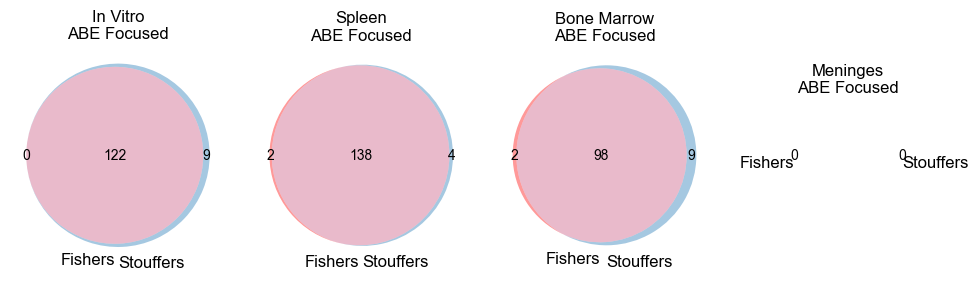

In [15]:
from matplotlib_venn import venn2

fig, axe =plt.subplots(1,4, figsize=(10,6))

for idx, tissue in enumerate(conditions_focused):

    list1 = fishers_hits_ABE_focused[idx]
    list2 = stouffers_hits_ABE_focused[idx]
    venn2([set(list1), set(list2)], set_labels=('Fishers', 'Stouffers'), set_colors=("red", "tab:blue"), ax=axe[idx])
    axe[idx].set_title(f'{name_dict_focused[tissue]}\nABE Focused')

fig.tight_layout()

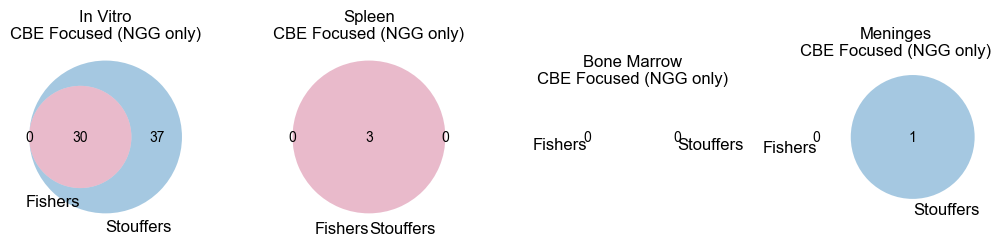

In [16]:
from matplotlib_venn import venn2

fig, axe =plt.subplots(1,4, figsize=(10,6))

for idx, tissue in enumerate(conditions_focused):

    list1 = fishers_hits_CBE_focused[idx]
    list2 = stouffers_hits_CBE_focused[idx]
    venn2([set(list1), set(list2)], set_labels=('Fishers', 'Stouffers'), set_colors=("red", "tab:blue"), ax=axe[idx])
    axe[idx].set_title(f'{name_dict_focused[tissue]}\nCBE Focused (NGG only)')

fig.tight_layout()

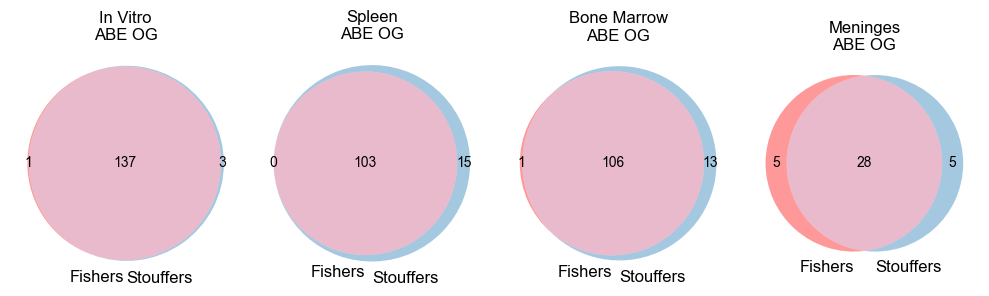

In [17]:
from matplotlib_venn import venn2

fig, axe =plt.subplots(1,4, figsize=(10,6))

for idx, tissue in enumerate(conditions_og):

    list1 = fishers_hits_ABE_og[idx]
    list2 = stouffers_hits_ABE_og[idx]
    venn2([set(list1), set(list2)], set_labels=('Fishers', 'Stouffers'), set_colors=("red", "tab:blue"), ax=axe[idx])
    axe[idx].set_title(f'{name_dict_og[tissue]}\nABE OG')

fig.tight_layout()

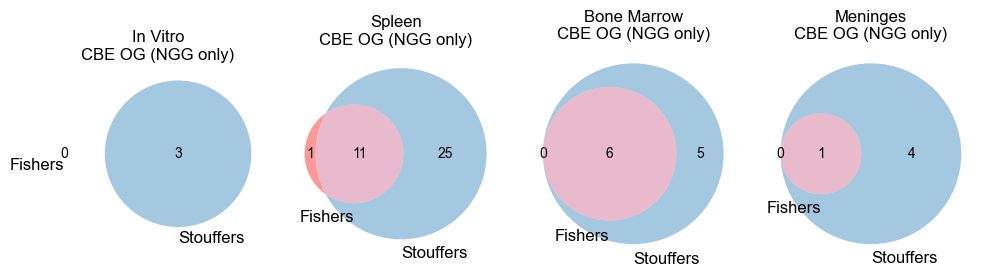

In [18]:
from matplotlib_venn import venn2

fig, axe =plt.subplots(1,4, figsize=(10,6))

for idx, tissue in enumerate(conditions_og):

    list1 = fishers_hits_CBE_og[idx]
    list2 = stouffers_hits_CBE_og[idx]
    venn2([set(list1), set(list2)], set_labels=('Fishers', 'Stouffers'), set_colors=("red", "tab:blue"), ax=axe[idx])
    axe[idx].set_title(f'{name_dict_og[tissue]}\nCBE OG (NGG only)')

fig.tight_layout()

## For the vs bc FDR calculation

In [19]:
print(list(LFC_CBE.columns))

['gRNA_id', 'Gene', 'bm1', 'bm2', 'bm3', 'bm4', 'bm5', 'LFC_avg_bm', 'LFC_median_bm', 'Input_median', 'd15-rep1', 'd15-rep2', 'd15-rep3', 'd15-rep4', 'd15-rep5', 'LFC_avg_d15', 'LFC_median_d15', 'd5-rep1', 'd5-rep2', 'd5-rep3', 'd5-rep4', 'd5-rep5', 'LFC_avg_d5', 'LFC_median_d5', 'input-rep1', 'input-rep2', 'input-rep3', 'input-rep4', 'input-rep5', 'LFC_avg_input', 'LFC_median_input', 'lib', 'LFC_avg_lib', 'LFC_median_lib', 'men1', 'men2', 'men3', 'men4', 'men5', 'LFC_avg_men', 'LFC_median_men', 'spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5', 'LFC_avg_spleen', 'LFC_median_spleen', 'sensor_reads', 'corr_perc', 'target_base_edit_perc', 'byproduct_INDEL_perc', 'byproduct_sub_perc', 'gene_name_m_corrected', 'gene_name_h', 'HGVSp_m', 'HGVSp_h', 'classification', 'classification_m', 'p_high_unadjusted_d5_fishers', 'p_low_unadjusted_d5_fishers', 'FDR_high_d5_fishers', 'FDR_low_d5_fishers', 'p_high_unadjusted_d5_stouffers', 'p_low_unadjusted_d5_stouffers', 'FDR_high_d5_stouffers', 'FDR_

In [20]:
print(list(LFC_CBE_OG.columns))

['gRNA_id', 'Gene', 'spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5', 'spleen6', 'spleen7', 'spleen8', 'spleen9', 'LFC_avg_spleen', 'LFC_median_spleen', 'Input_median', 'bonemarrow1', 'bonemarrow2', 'bonemarrow3', 'bonemarrow4', 'bonemarrow5', 'bonemarrow6', 'bonemarrow7', 'bonemarrow8', 'bonemarrow9', 'bonemarrow10', 'LFC_avg_bonemarrow', 'LFC_median_bonemarrow', 'meninges1', 'meninges2', 'meninges3', 'meninges4', 'meninges5', 'meninges6', 'meninges7', 'meninges8', 'meninges9', 'meninges10', 'LFC_avg_meninges', 'LFC_median_meninges', 'd5_rep1', 'd5_rep2', 'd5_rep3', 'LFC_avg_d5', 'LFC_median_d5', 'd15_rep1', 'd15_rep2', 'd15_rep3', 'LFC_avg_d15', 'LFC_median_d15', 'plasmidlib', 'LFC_avg_plasmid_lib', 'LFC_median_plasmid_lib', 'sensor_reads', 'corr_perc', 'target_base_edit_perc', 'byproduct_INDEL_perc', 'byproduct_sub_perc', 'gene_name_m_corrected', 'gene_name_h', 'HGVSp_m', 'HGVSp_h', 'classification', 'classification_m', 'p_high_unadjusted_d5_fishers', 'p_low_unadjusted_d5_fishe

In [21]:
list_NGG_PAM = [f'{x}GG' for x in ['A','T','G','C']]
guides_NGG_CBE_focused = list(LIB[ (LIB['Editor']=='CBE') & (LIB['PAM_NGN'].isin(list_NGG_PAM)) ]['gRNA_id'])
guides_NGG_CBE_og = list(LIB_OG[ (LIB_OG['Editor']=='CBE') & (LIB_OG['PAM_NGN'].isin(list_NGG_PAM)) ]['gRNA_id'])
len(guides_NGG_CBE_focused)

271

In [22]:
len(guides_NGG_CBE_og)

3532

In [23]:
#and perform comparison
FDR_cutoff = .1
input_reads_cutoff = 100

above_threshold_gRNAs_focused_bc = list(LFC_CBE_VS_BC[(LFC_CBE_VS_BC['sensor_reads_epo']>=input_reads_cutoff) & (LFC_CBE_VS_BC['sensor_reads_bc']>=input_reads_cutoff) & (LFC_CBE_VS_BC['gRNA_id'].isin(guides_NGG_CBE_focused)) ]['gRNA_id']) + list(LFC_ABE_VS_BC[ (LFC_ABE_VS_BC['sensor_reads_bc']>=input_reads_cutoff) & (LFC_ABE_VS_BC['sensor_reads_epo']>=input_reads_cutoff)]['gRNA_id'])

In [24]:
len(above_threshold_gRNAs_focused_bc)


439

In [31]:
# for focused library
fishers_hits_CBE_focused_bc = []
fishers_hits_ABE_focused_bc = []
stouffers_hits_CBE_focused_bc = []
stouffers_hits_ABE_focused_bc = []

conditions_focused = ['d15', 'spleen', 'bm', 'men']
name_dict_focused = dict(zip(
    conditions_focused,
    ['In Vitro','Spleen','Bone Marrow', 'Meninges']
))

In [32]:

for tissue in conditions_focused:
    # fishers
        # focused
    ABE_fishers = LFC_ABE_VS_BC[(LFC_ABE_VS_BC[f'FDR_{tissue}_fishers']<FDR_cutoff) & (LFC_ABE_VS_BC['gRNA_id'].isin(above_threshold_gRNAs_focused_bc))]
    CBE_NGG_fishers = LFC_CBE_VS_BC[(LFC_CBE_VS_BC[f'FDR_{tissue}_fishers']<FDR_cutoff) & (LFC_CBE_VS_BC['gRNA_id'].isin(above_threshold_gRNAs_focused_bc))]

    # stouffers
        # focused
    ABE_stouffers = LFC_ABE_VS_BC[(LFC_ABE_VS_BC[f'FDR_{tissue}_stouffers']<FDR_cutoff) & (LFC_ABE_VS_BC['gRNA_id'].isin(above_threshold_gRNAs_focused_bc))]
    CBE_NGG_stouffers = LFC_CBE_VS_BC[(LFC_CBE_VS_BC[f'FDR_{tissue}_stouffers']<FDR_cutoff) & (LFC_CBE_VS_BC['gRNA_id'].isin(above_threshold_gRNAs_focused_bc))]

    fishers_hits_ABE_focused_bc.append(list(ABE_fishers['gRNA_id']))
    fishers_hits_CBE_focused_bc.append(list(CBE_NGG_fishers['gRNA_id']))

    stouffers_hits_ABE_focused_bc.append(list(ABE_stouffers['gRNA_id']))
    stouffers_hits_CBE_focused_bc.append(list(CBE_NGG_stouffers['gRNA_id']))

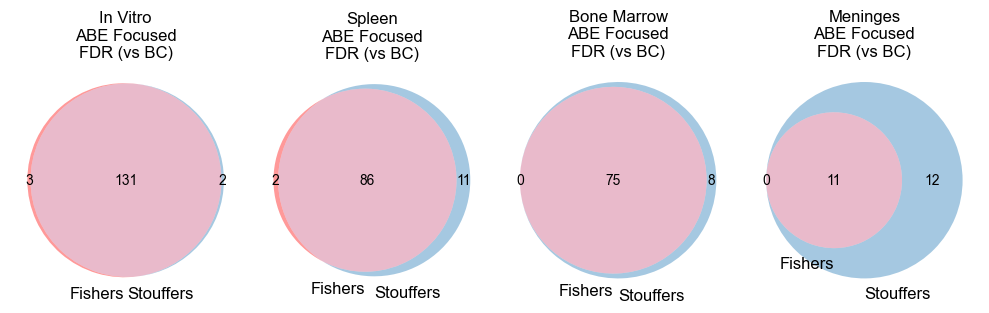

In [27]:
from matplotlib_venn import venn2

fig, axe =plt.subplots(1,4, figsize=(10,6))

for idx, tissue in enumerate(conditions_focused):

    list1 = fishers_hits_ABE_focused_bc[idx]
    list2 = stouffers_hits_ABE_focused_bc[idx]
    venn2([set(list1), set(list2)], set_labels=('Fishers', 'Stouffers'), set_colors=("red", "tab:blue"), ax=axe[idx])
    axe[idx].set_title(f'{name_dict_focused[tissue]}\nABE Focused\nFDR (vs BC)')

fig.tight_layout()

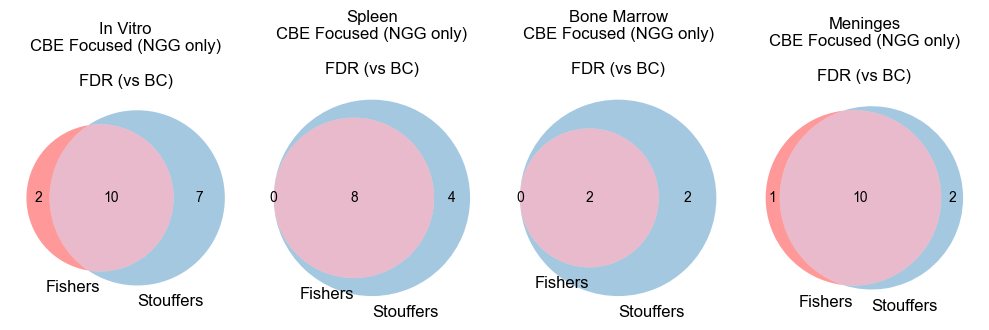

In [28]:
from matplotlib_venn import venn2

fig, axe =plt.subplots(1,4, figsize=(10,6))

for idx, tissue in enumerate(conditions_focused):

    list1 = fishers_hits_CBE_focused_bc[idx]
    list2 = stouffers_hits_CBE_focused_bc[idx]
    venn2([set(list1), set(list2)], set_labels=('Fishers', 'Stouffers'), set_colors=("red", "tab:blue"), ax=axe[idx])
    axe[idx].set_title(f'{name_dict_focused[tissue]}\nCBE Focused (NGG only)\n\nFDR (vs BC)')

fig.tight_layout()

## Compare T0 baseline and BC baseline
FDR = .1, Fishers

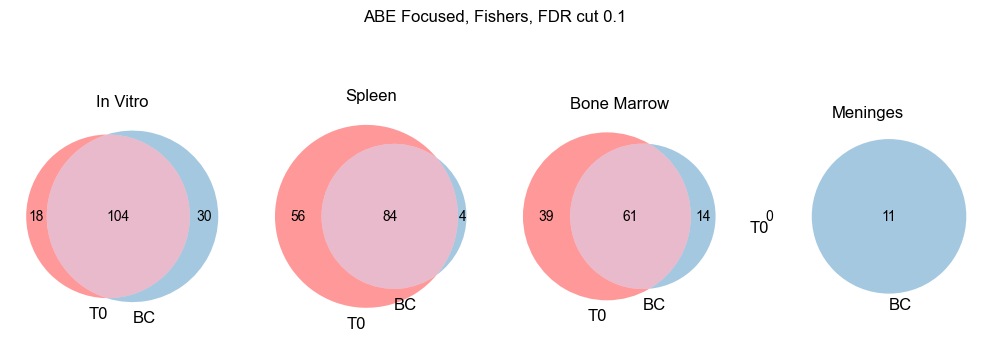

In [36]:
from matplotlib_venn import venn2

fig, axe =plt.subplots(1,4, figsize=(10,4))

for idx, tissue in enumerate(conditions_focused):

    list1 = fishers_hits_ABE_focused[idx]
    list2 = fishers_hits_ABE_focused_bc[idx]
    venn2([set(list1), set(list2)], set_labels=('T0', 'BC'), set_colors=("red", "tab:blue"), ax=axe[idx])
    axe[idx].set_title(f'{name_dict_focused[tissue]}')

plt.suptitle('ABE Focused, Fishers, FDR cut 0.1')
fig.tight_layout()
plt.savefig('figures/venn_t0_bc_abe.pdf')

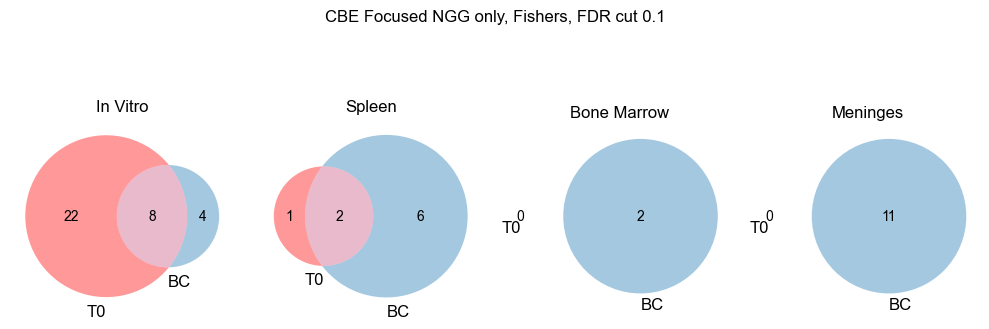

In [37]:
from matplotlib_venn import venn2

fig, axe =plt.subplots(1,4, figsize=(10,4))

for idx, tissue in enumerate(conditions_focused):

    list1 = fishers_hits_CBE_focused[idx]
    list2 = fishers_hits_CBE_focused_bc[idx]
    venn2([set(list1), set(list2)], set_labels=('T0', 'BC'), set_colors=("red", "tab:blue"), ax=axe[idx])
    axe[idx].set_title(f'{name_dict_focused[tissue]}')

plt.suptitle('CBE Focused NGG only, Fishers, FDR cut 0.1')
fig.tight_layout()
plt.savefig('figures/venn_t0_bc_cbe.pdf')

### Further add a filter of editing efficiency ≥ 20

In [167]:
#further filter by editing rate
edit_cutoff = 20
high_edit_gRNAs = set(list(LFC_CBE[LFC_CBE['target_base_edit_perc']>=20]['gRNA_id']) + list(LFC_ABE[LFC_ABE['target_base_edit_perc']>=20]['gRNA_id']))

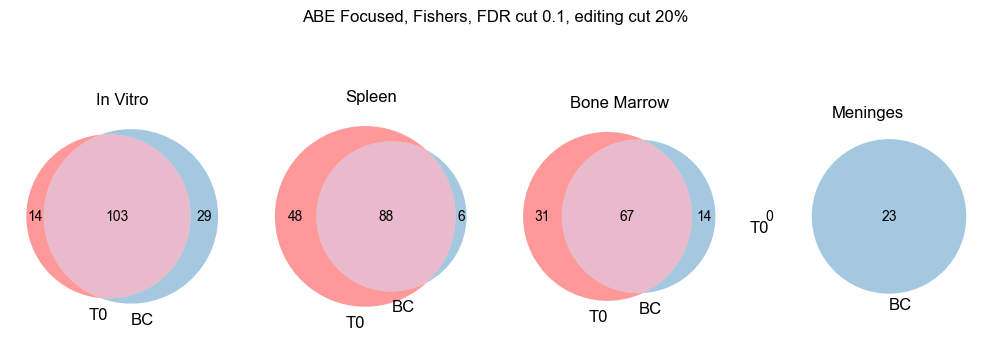

In [ ]:
from matplotlib_venn import venn2

fig, axe =plt.subplots(1,4, figsize=(10,4))

for idx, tissue in enumerate(conditions_focused):

    list1 = fishers_hits_ABE_focused[idx]
    list2 = stouffers_hits_ABE_focused_bc[idx]

    list11 = high_edit_gRNAs & set(list1)
    list22 = high_edit_gRNAs & set(list2)

    venn2([set(list11), set(list22)], set_labels=('T0', 'BC'), set_colors=("red", "tab:blue"), ax=axe[idx])
    axe[idx].set_title(f'{name_dict_focused[tissue]}')

plt.suptitle('ABE Focused, Fishers, FDR cut 0.1, editing cut 20%')
fig.tight_layout()
plt.savefig('figures/venn_t0_bc_abe_editing_20.pdf')

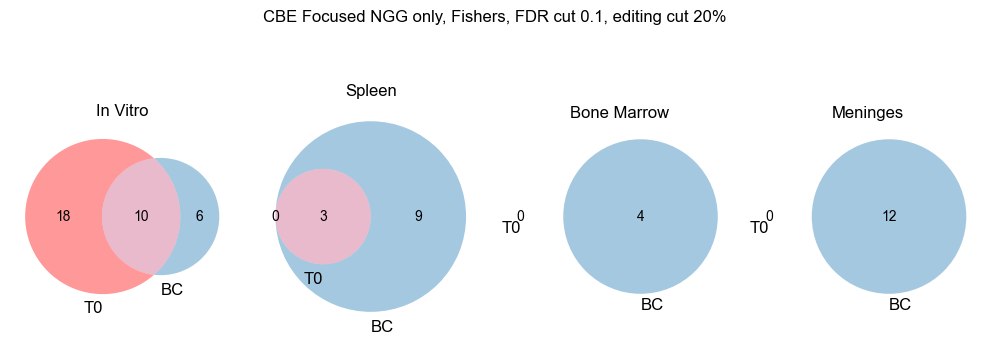

In [170]:
from matplotlib_venn import venn2

fig, axe =plt.subplots(1,4, figsize=(10,4))

for idx, tissue in enumerate(conditions_focused):

    list1 = fishers_hits_CBE_focused[idx]
    list2 = stouffers_hits_CBE_focused_bc[idx]

    list11 = high_edit_gRNAs & set(list1)
    list22 = high_edit_gRNAs & set(list2)
    
    venn2([set(list11), set(list22)], set_labels=('T0', 'BC'), set_colors=("red", "tab:blue"), ax=axe[idx])
    axe[idx].set_title(f'{name_dict_focused[tissue]}')

plt.suptitle('CBE Focused NGG only, Fishers, FDR cut 0.1, editing cut 20%')
fig.tight_layout()
plt.savefig('figures/venn_t0_bc_cbe_editing_20.pdf')

# Compare hits of the OG screen and the focused screen

Need to restrict guides to plot to the guides that are included in the ABE and CBE focused libraries.

- fishers
- input read counts of n = 10 (for OG) and n = 100 (for focused);
- FDR = 0.1; 
- filter CBE to CBE NGG guides only;
- editing efficiency ≥ 20%.

In [184]:
#further filter by editing rate
edit_cutoff = 20
high_edit_gRNAs_focused = set(list(LFC_CBE[LFC_CBE['target_base_edit_perc']>=20]['gRNA_id']) + list(LFC_ABE[LFC_ABE['target_base_edit_perc']>=20]['gRNA_id']))
high_edit_gRNAs_og = set(list(LFC_CBE_OG[LFC_CBE_OG['target_base_edit_perc']>=20]['gRNA_id']) + list(LFC_ABE_OG[LFC_ABE_OG['target_base_edit_perc']>=20]['gRNA_id']))
focused_library_guides = set(list(LFC_ABE['gRNA_id']) + list(LFC_CBE['gRNA_id']))

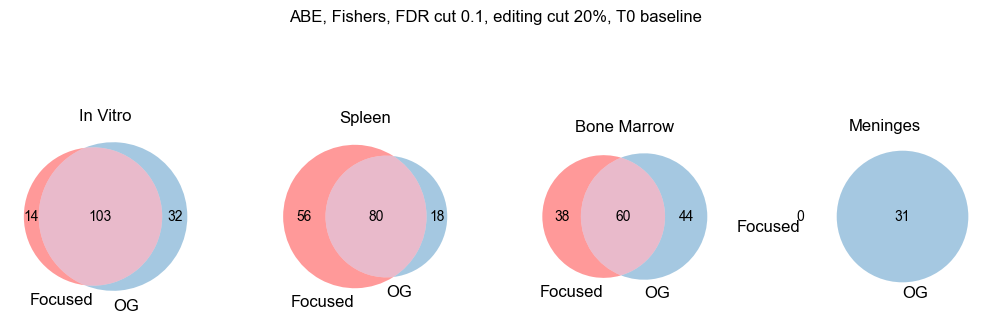

In [190]:
from matplotlib_venn import venn2
high_edit_gRNAs_focused = set(list(LFC_CBE[LFC_CBE['target_base_edit_perc']>=20]['gRNA_id']) + list(LFC_ABE[LFC_ABE['target_base_edit_perc']>=20]['gRNA_id']))
high_edit_gRNAs_og = set(list(LFC_CBE_OG[LFC_CBE_OG['target_base_edit_perc']>=20]['gRNA_id']) + list(LFC_ABE_OG[LFC_ABE_OG['target_base_edit_perc']>=20]['gRNA_id']))

fig, axe =plt.subplots(1,4, figsize=(10,4))

for idx, tissue in enumerate(conditions_focused):

    list1 = fishers_hits_ABE_focused[idx]
    list2 = fishers_hits_ABE_og[idx]

    list11 = high_edit_gRNAs_focused & set(list1)
    list22 = high_edit_gRNAs_og & set(list2) & focused_library_guides

    venn2([set(list11), set(list22)], set_labels=('Focused', 'OG'), set_colors=("red", "tab:blue"), ax=axe[idx])
    axe[idx].set_title(f'{name_dict_focused[tissue]}')

plt.suptitle('ABE, Fishers, FDR cut 0.1, editing cut 20%, T0 baseline')
fig.tight_layout()
plt.savefig('figures/abe_venn_og_focused.pdf')

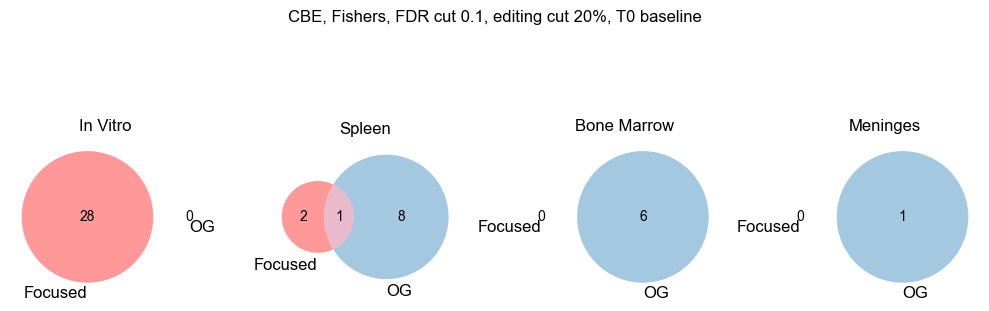

In [189]:
from matplotlib_venn import venn2
high_edit_gRNAs_focused = set(list(LFC_CBE[LFC_CBE['target_base_edit_perc']>=20]['gRNA_id']) + list(LFC_ABE[LFC_ABE['target_base_edit_perc']>=20]['gRNA_id']))
high_edit_gRNAs_og = set(list(LFC_CBE_OG[LFC_CBE_OG['target_base_edit_perc']>=20]['gRNA_id']) + list(LFC_ABE_OG[LFC_ABE_OG['target_base_edit_perc']>=20]['gRNA_id']))

fig, axe =plt.subplots(1,4, figsize=(10,4))

for idx, tissue in enumerate(conditions_focused):

    list1 = fishers_hits_CBE_focused[idx]
    list2 = fishers_hits_CBE_og[idx]

    list11 = high_edit_gRNAs_focused & set(list1)
    list22 = high_edit_gRNAs_og & set(list2) & focused_library_guides

    venn2([set(list11), set(list22)], set_labels=('Focused', 'OG'), set_colors=("red", "tab:blue"), ax=axe[idx])
    axe[idx].set_title(f'{name_dict_focused[tissue]}')

plt.suptitle('CBE, Fishers, FDR cut 0.1, editing cut 20%, T0 baseline')
fig.tight_layout()
plt.savefig('figures/cbe_venn_og_focused.pdf')

# Waterfall plots of all hits in different tissues

I am going to plot this with:  
- traditional null distribution LFC;
- fishers FDR;
- input reads cut = 100;
- no FDR cut;
- editing percentage cut = **0, 20, 50, and 90**.

# Waterfall plots of all the guides in p53 and pax5 in all tissues

In [ ]:
list(combined_LFC_FDR_ABE.columns)

['gRNA_id',
 'Gene',
 'bm1',
 'bm2',
 'bm3',
 'bm4',
 'bm5',
 'LFC_avg_bm',
 'LFC_median_bm',
 'Input_median',
 'd15-rep1',
 'd15-rep2',
 'd15-rep3',
 'd15-rep4',
 'd15-rep5',
 'LFC_avg_d15',
 'LFC_median_d15',
 'd5',
 'LFC_avg_d5',
 'LFC_median_d5',
 'input',
 'LFC_avg_input',
 'LFC_median_input',
 'lib',
 'LFC_avg_lib',
 'LFC_median_lib',
 'men1',
 'men2',
 'men3',
 'men4',
 'men5',
 'LFC_avg_men',
 'LFC_median_men',
 'spleen1',
 'spleen2',
 'spleen3',
 'spleen4',
 'spleen5',
 'LFC_avg_spleen',
 'LFC_median_spleen',
 'sensor_reads',
 'corr_perc',
 'target_base_edit_perc',
 'byproduct_INDEL_perc',
 'byproduct_sub_perc',
 'gene_name_m_corrected',
 'gene_name_h',
 'HGVSp_m',
 'HGVSp_h',
 'classification',
 'classification_m',
 'p_high_unadjusted_d5_fishers',
 'p_low_unadjusted_d5_fishers',
 'FDR_high_d5_fishers',
 'FDR_low_d5_fishers',
 'p_high_unadjusted_d5_stouffers',
 'p_low_unadjusted_d5_stouffers',
 'FDR_high_d5_stouffers',
 'FDR_low_d5_stouffers',
 'FDR_d5_fishers',
 'FDR_d5_stouf

In [ ]:

cc2 = cc2[cc2['FDR']<=fdr_cut]
cc2 = cc2[cc2['target_prime_edit_perc']>=edit_cutoff]
cc2['Rank'] = np.arange(1, len(cc2)+1)
fig, ax = plt.subplots(figsize=(3,7))

color_dict_2 = {True:'darkred', False:'grey'}
cc2['color'] = 'darkblue'
ax.scatter(cc2['Rank'], cc2[f'LFC'],color=cc2['color'], s=30)

ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=16,)
ax.plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
ax.set_xlabel('gRNA Rank', fontsize=16)

#and annotate top and bottom 5 variant
top = cc2[:5]
bottom = cc2[-5:]
tb = pd.concat((top, bottom))

t = []
x = []
y = []
c = []

# print(val)
for i, val2 in tb.iterrows():
    y.append(val2[f'LFC'])
    x.append(val2['Rank'])
    c.append(val2['color'])
    a = str(val2['HGVSp_m'])
    if a == 'nan':
        a = 'Non-coding'
    if a=='Not calculated (legacy)':
        a = val2['HGVSp_h'] + ' (human)'
    t.append(f'{a}')

    print(f'{val2["Rank"]} {a} {val2["color"]}')
texts = [ax.text(x[i], y[i], t[i], fontsize=15, color=c[i], path_effects=[PathEffects.withStroke(linewidth=3,foreground="w")]) for i in range(len(x))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

adjust_text(texts, only_move={'points':'xy', 'texts':'xy'}, ax=ax, arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'))
#ax.set_ylim(0,20)

ax.set_ylabel('LFC (vs. Input)', fontsize=18)
ax.set_title('DMSO | Trp53\n>5% editing, FDR<.2', fontsize=16)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.savefig(f'figures/Trp53.pdf', bbox_inches='tight')
fig.tight_layout()

1 L249P #afaed4
2 K117R #afaed4
3 H176R #afaed4
4 N236S #afaed4
5 I248T #afaed4
6 M243T #afaed4
7 M243T #afaed4
1 L249P #afaed4
2 K117R #afaed4
3 M243T #afaed4
4 R277G #afaed4
5 I248T #afaed4
6 D278G #afaed4
7 N236S #afaed4
1 L249P #afaed4
2 H176R #afaed4
3 I248T #afaed4
4 K117R #afaed4
5 M243T #afaed4
6 R277G #afaed4
7 Non-coding #afaed4
1 L249P #afaed4
3 K117R #afaed4
4 R277G #afaed4
5 N236S #afaed4
6 Non-coding #afaed4


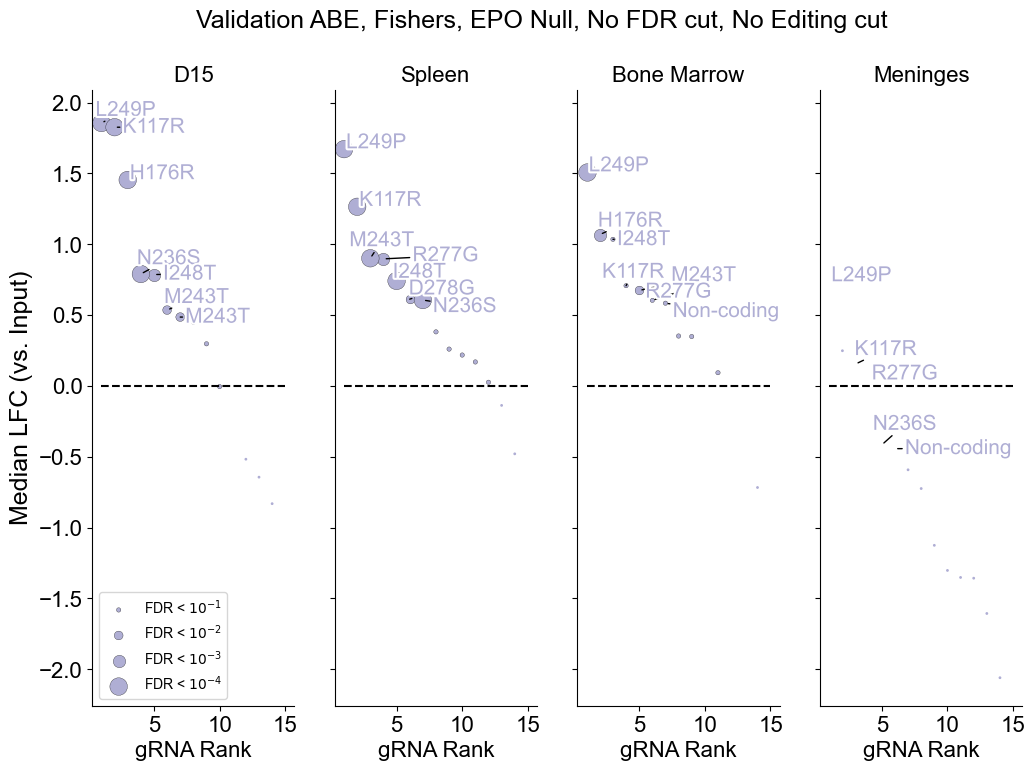

In [ ]:
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
min_edit = 0
FDR_cutoff = .5
min_input_counts = 100
gene_of_interest = 'Trp53'
greens  = sns.color_palette('Greens').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
blues = sns.color_palette('Blues').as_hex()
purples = sns.color_palette('Purples').as_hex()
ABE_targ = combined_LFC_FDR_ABE[(combined_LFC_FDR_ABE['classification']=='targeting guide')& (combined_LFC_FDR_ABE['target_base_edit_perc']>=min_edit) & (combined_LFC_FDR_ABE['Input_median']>=min_input_counts)
                                & (combined_LFC_FDR_ABE['Gene']==gene_of_interest)]
#-----and plotting--------
names2 = ['d15','spleen', 'bm', 'men',]
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}
fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

for k, val in enumerate(names2):
    #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
    #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
    #cc2 = cc2.sort_values(by='LFC', ascending=False)

    cc2 = ABE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)
    cc2['Rank'] = np.arange(1, len(cc2)+1)
    cc2['color'] = purples[2]

    #split by significance level

    cc2_other = cc2[cc2[f'FDR_{val}_fishers']>=FDR_cutoff]
    ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}'], color=cc2_other['color'], s=1)

    #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

    FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

    size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
    label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

   # for id1, cut in enumerate(FDR_cutoffs):
     #   if id1==0:
     #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
            
     #   else:
     #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

      #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

    for id1, cut in enumerate(FDR_cutoffs):
        if id1==3:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut)]
            
        else:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut) &(cc2[f'FDR_{val}_fishers']>=FDR_cutoffs[id1+1])]

        ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black')

    if k==0:
        ax[k].legend(loc='lower left')

    #------making plot pretty------

    ax[k].spines[['top', 'right']].set_visible(False)
    ax[k].tick_params(axis='both', which='major', labelsize=16,)
    ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
    ax[k].set_xlabel('gRNA Rank', fontsize=16)

    #and annotate top and bottom 5 variant
    cc3 = cc2[cc2[f'FDR_{val}_fishers']<FDR_cutoff]
    top = cc3[:7]
    tb = top
    t = []
    x = []
    y = []
    c = []

    # print(val)
    for i, val2 in tb.iterrows():
        y.append(val2[f'LFC_median_{val}'])
        x.append(val2['Rank'])
        c.append(val2['color'])
        a = str(val2['HGVSp_m'])
        if a == 'nan':
            a = 'Non-coding'
        if a=='Not calculated (legacy)':
            a = val2['HGVSp_h'] + ' (human)'
        t.append(f'{a}')

        print(f'{val2["Rank"]} {a} {val2["color"]}')
    texts = [ax[k].text(x[i], y[i], t[i], fontsize=15, color=c[i], path_effects=[PathEffects.withStroke(linewidth=3,foreground="w")]) for i in range(len(x))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

    adjust_text(texts, only_move={'points':'xy', 'texts':'xy'}, ax=ax[k], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'))
#ax.set_ylim(0,20)

ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
ax[0].set_title('D15', fontsize=16)
ax[1].set_title('Spleen', fontsize=16)
ax[2].set_title('Bone Marrow', fontsize=16)
ax[3].set_title('Meninges', fontsize=16)
plt.suptitle('Validation ABE, Fishers, EPO Null, No FDR cut, No Editing cut',fontsize=18)
fig.savefig('figures/waterfall_trp53_fishers_epo_null_abe.png', dpi=300, transparent=True)

1 L249P #afaed4
2 K117R #afaed4
3 H176R #afaed4
4 N236S #afaed4
5 I248T #afaed4
6 M243T #afaed4
7 M243T #afaed4
1 L249P #afaed4
2 K117R #afaed4
3 M243T #afaed4
4 R277G #afaed4
5 I248T #afaed4
7 N236S #afaed4
1 L249P #afaed4
2 H176R #afaed4
3 I248T #afaed4
4 K117R #afaed4
5 M243T #afaed4
6 R277G #afaed4
7 Non-coding #afaed4


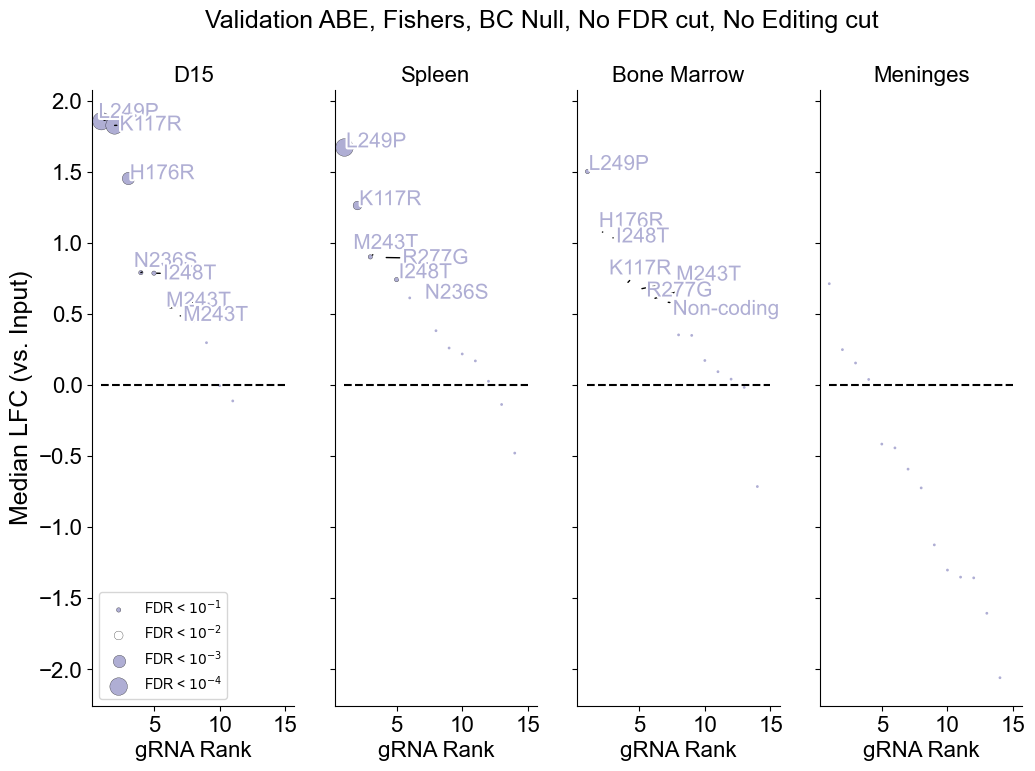

In [ ]:
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
min_edit = 0
FDR_cutoff = .5
min_input_counts = 100
gene_of_interest = 'Trp53'
df = combined_LFC_FDR_ABE_bc

greens  = sns.color_palette('Greens').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
blues = sns.color_palette('Blues').as_hex()
purples = sns.color_palette('Purples').as_hex()


ABE_targ = df[(df['classification']=='targeting guide')& (df['target_base_edit_perc']>=min_edit) & (df['Input_median']>=min_input_counts)
                                & (df['Gene']==gene_of_interest)]
#-----and plotting--------
names2 = ['d15','spleen', 'bm', 'men',]
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}
fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

for k, val in enumerate(names2):
    #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
    #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
    #cc2 = cc2.sort_values(by='LFC', ascending=False)

    cc2 = ABE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)
    cc2['Rank'] = np.arange(1, len(cc2)+1)
    cc2['color'] = purples[2]

    #split by significance level

    cc2_other = cc2[cc2[f'FDR_{val}_fishers']>=FDR_cutoff]
    ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}'], color=cc2_other['color'], s=1)

    #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

    FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

    size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
    label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

   # for id1, cut in enumerate(FDR_cutoffs):
     #   if id1==0:
     #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
            
     #   else:
     #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

      #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

    for id1, cut in enumerate(FDR_cutoffs):
        if id1==3:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut)]
            
        else:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut) &(cc2[f'FDR_{val}_fishers']>=FDR_cutoffs[id1+1])]

        ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black')

    if k==0:
        ax[k].legend(loc='lower left')

    #------making plot pretty------

    ax[k].spines[['top', 'right']].set_visible(False)
    ax[k].tick_params(axis='both', which='major', labelsize=16,)
    ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
    ax[k].set_xlabel('gRNA Rank', fontsize=16)

    #and annotate top and bottom 5 variant
    cc3 = cc2[cc2[f'FDR_{val}_fishers']<FDR_cutoff]
    top = cc3[:7]
    tb = top
    t = []
    x = []
    y = []
    c = []

    # print(val)
    for i, val2 in tb.iterrows():
        y.append(val2[f'LFC_median_{val}'])
        x.append(val2['Rank'])
        c.append(val2['color'])
        a = str(val2['HGVSp_m'])
        if a == 'nan':
            a = 'Non-coding'
        if a=='Not calculated (legacy)':
            a = val2['HGVSp_h'] + ' (human)'
        t.append(f'{a}')

        print(f'{val2["Rank"]} {a} {val2["color"]}')
    texts = [ax[k].text(x[i], y[i], t[i], fontsize=15, color=c[i], path_effects=[PathEffects.withStroke(linewidth=3,foreground="w")]) for i in range(len(x))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

    adjust_text(texts, only_move={'points':'xy', 'texts':'xy'}, ax=ax[k], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'))
#ax.set_ylim(0,20)

ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
ax[0].set_title('D15', fontsize=16)
ax[1].set_title('Spleen', fontsize=16)
ax[2].set_title('Bone Marrow', fontsize=16)
ax[3].set_title('Meninges', fontsize=16)
plt.suptitle('Validation ABE, Fishers, BC Null, No FDR cut, No Editing cut',fontsize=18)
fig.savefig('figures/waterfall_trp53_fishers_bc_null_abe.png', dpi=300, transparent=True)

1 p.W91* (human) #89bedc
3 R193Q #89bedc
4 Non-coding #89bedc
5 R270C #89bedc
6 R178C #89bedc
7 A158T #89bedc
9 A158T #89bedc
3 C138Y #89bedc


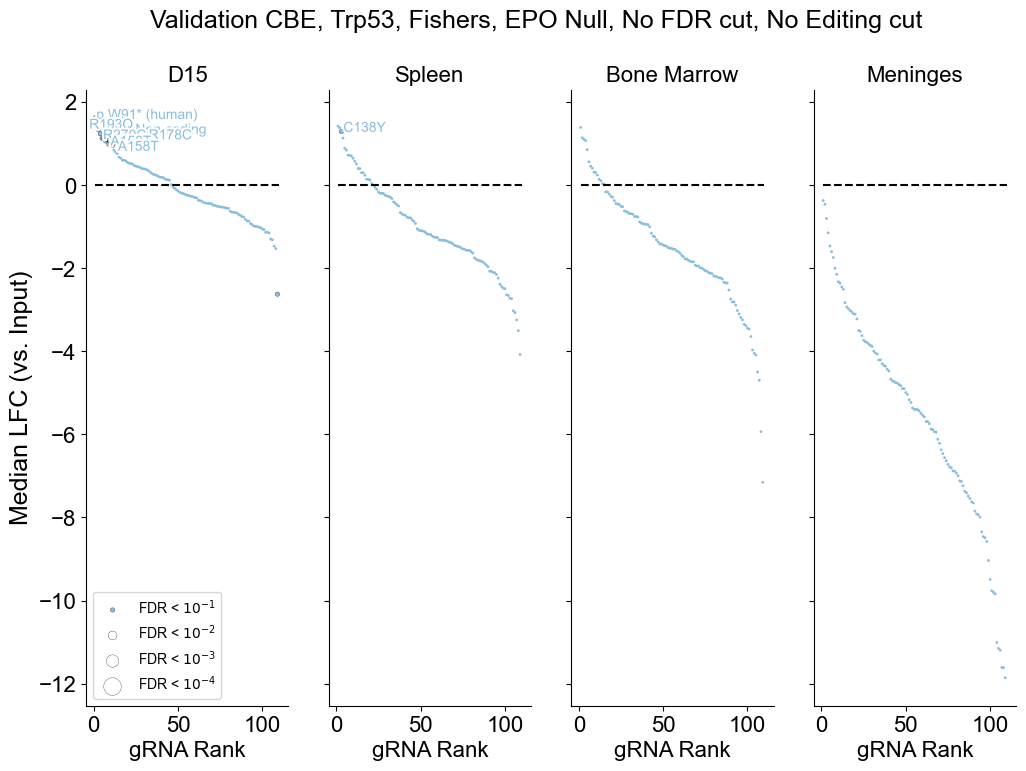

In [ ]:
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
min_edit = 0
FDR_cutoff = .1
min_input_counts = 100
gene_of_interest = 'Trp53'
df = combined_LFC_FDR_CBE

greens  = sns.color_palette('Greens').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
blues = sns.color_palette('Blues').as_hex()
purples = sns.color_palette('Purples').as_hex()


ABE_targ = df[(df['classification']=='targeting guide')& (df['target_base_edit_perc']>=min_edit) & (df['Input_median']>=min_input_counts)
                                & (df['Gene']==gene_of_interest)]
#-----and plotting--------
names2 = ['d15','spleen', 'bm', 'men',]
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}
fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

for k, val in enumerate(names2):
    #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
    #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
    #cc2 = cc2.sort_values(by='LFC', ascending=False)

    cc2 = ABE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)
    cc2['Rank'] = np.arange(1, len(cc2)+1)
    cc2['color'] = blues[2]

    #split by significance level

    cc2_other = cc2[cc2[f'FDR_{val}_fishers']>=FDR_cutoff]
    ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}'], color=cc2_other['color'], s=1)

    #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

    FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

    size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
    label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

   # for id1, cut in enumerate(FDR_cutoffs):
     #   if id1==0:
     #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
            
     #   else:
     #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

      #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

    for id1, cut in enumerate(FDR_cutoffs):
        if id1==3:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut)]
            
        else:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut) &(cc2[f'FDR_{val}_fishers']>=FDR_cutoffs[id1+1])]

        ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black')

    if k==0:
        ax[k].legend(loc='lower left')

    #------making plot pretty------

    ax[k].spines[['top', 'right']].set_visible(False)
    ax[k].tick_params(axis='both', which='major', labelsize=16,)
    ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
    ax[k].set_xlabel('gRNA Rank', fontsize=16)

    #and annotate top and bottom 5 variant
    cc3 = cc2[cc2[f'FDR_{val}_fishers']<FDR_cutoff]
    top = cc3[:7]
    tb = top
    t = []
    x = []
    y = []
    c = []

    # print(val)
    for i, val2 in tb.iterrows():
        y.append(val2[f'LFC_median_{val}'])
        x.append(val2['Rank'])
        c.append(val2['color'])
        a = str(val2['HGVSp_m'])
        if a == 'nan':
            a = 'Non-coding'
        if a=='Not calculated (legacy)':
            a = val2['HGVSp_h'] + ' (human)'
        t.append(f'{a}')

        print(f'{val2["Rank"]} {a} {val2["color"]}')
    texts = [ax[k].text(x[i], y[i], t[i], fontsize=10, color=c[i], path_effects=[PathEffects.withStroke(linewidth=3,foreground="w")]) for i in range(len(x))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

    adjust_text(texts, only_move={'points':'xy', 'texts':'xy'}, ax=ax[k], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'))
#ax.set_ylim(0,20)

ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
ax[0].set_title('D15', fontsize=16)
ax[1].set_title('Spleen', fontsize=16)
ax[2].set_title('Bone Marrow', fontsize=16)
ax[3].set_title('Meninges', fontsize=16)
plt.suptitle('Validation CBE, Trp53, Fishers, EPO Null, No FDR cut, No Editing cut',fontsize=18)
fig.savefig('figures/waterfall_trp53_fishers_epo_null_cbe.png', dpi=300, transparent=True)

1 R59Q #afaed4
2 R377Q #afaed4
3 R390H #afaed4
4 S134F #afaed4
5 G290R #afaed4
6 G290R #afaed4
7 G314R #afaed4
1 S134F #afaed4
2 W358* #afaed4
3 R38C #afaed4
1 W358* #afaed4


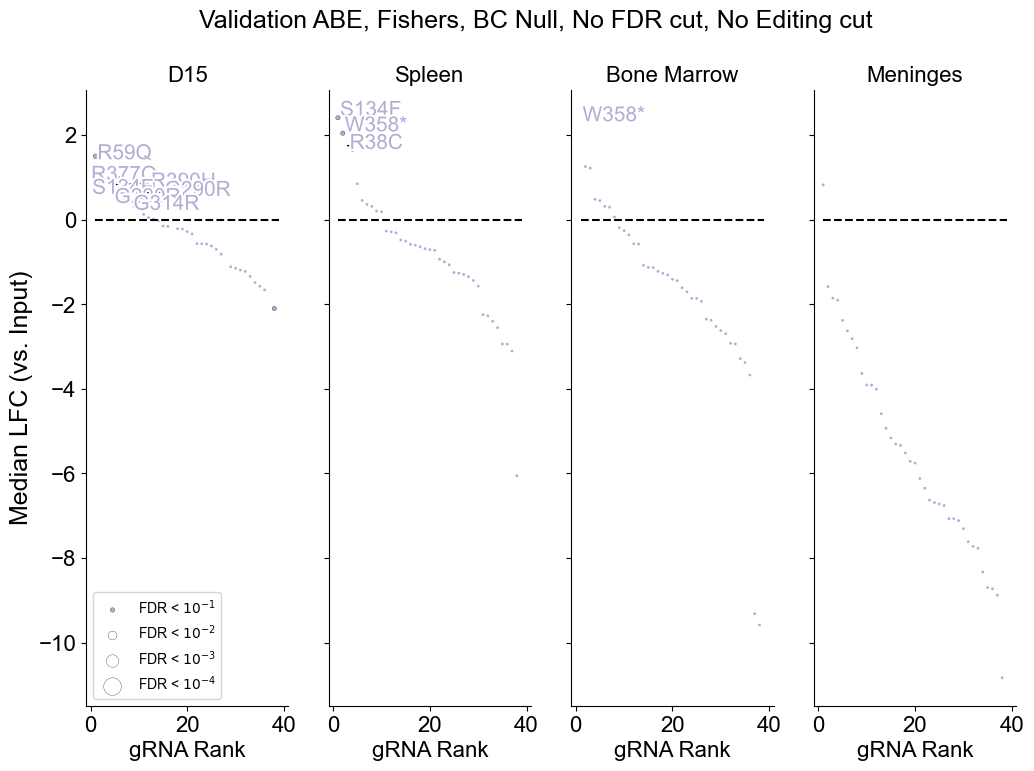

In [ ]:
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
min_edit = 0
FDR_cutoff = .5
min_input_counts = 100
gene_of_interest = 'Pax5'
df = combined_LFC_FDR_CBE

greens  = sns.color_palette('Greens').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
blues = sns.color_palette('Blues').as_hex()
purples = sns.color_palette('Purples').as_hex()


ABE_targ = df[(df['classification']=='targeting guide')& (df['target_base_edit_perc']>=min_edit) & (df['Input_median']>=min_input_counts)
                                & (df['Gene']==gene_of_interest)]
#-----and plotting--------
names2 = ['d15','spleen', 'bm', 'men',]
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}
fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

for k, val in enumerate(names2):
    #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
    #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
    #cc2 = cc2.sort_values(by='LFC', ascending=False)

    cc2 = ABE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)
    cc2['Rank'] = np.arange(1, len(cc2)+1)
    cc2['color'] = purples[2]

    #split by significance level

    cc2_other = cc2[cc2[f'FDR_{val}_fishers']>=FDR_cutoff]
    ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}'], color=cc2_other['color'], s=1)

    #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

    FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

    size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
    label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

   # for id1, cut in enumerate(FDR_cutoffs):
     #   if id1==0:
     #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
            
     #   else:
     #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

      #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

    for id1, cut in enumerate(FDR_cutoffs):
        if id1==3:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut)]
            
        else:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut) &(cc2[f'FDR_{val}_fishers']>=FDR_cutoffs[id1+1])]

        ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black')

    if k==0:
        ax[k].legend(loc='lower left')

    #------making plot pretty------

    ax[k].spines[['top', 'right']].set_visible(False)
    ax[k].tick_params(axis='both', which='major', labelsize=16,)
    ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
    ax[k].set_xlabel('gRNA Rank', fontsize=16)

    #and annotate top and bottom 5 variant
    cc3 = cc2[cc2[f'FDR_{val}_fishers']<FDR_cutoff]
    top = cc3[:7]
    tb = top
    t = []
    x = []
    y = []
    c = []

    # print(val)
    for i, val2 in tb.iterrows():
        y.append(val2[f'LFC_median_{val}'])
        x.append(val2['Rank'])
        c.append(val2['color'])
        a = str(val2['HGVSp_m'])
        if a == 'nan':
            a = 'Non-coding'
        if a=='Not calculated (legacy)':
            a = val2['HGVSp_h'] + ' (human)'
        t.append(f'{a}')

        print(f'{val2["Rank"]} {a} {val2["color"]}')
    texts = [ax[k].text(x[i], y[i], t[i], fontsize=15, color=c[i], path_effects=[PathEffects.withStroke(linewidth=3,foreground="w")]) for i in range(len(x))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

    adjust_text(texts, only_move={'points':'xy', 'texts':'xy'}, ax=ax[k], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'))
#ax.set_ylim(0,20)

ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
ax[0].set_title('D15', fontsize=16)
ax[1].set_title('Spleen', fontsize=16)
ax[2].set_title('Bone Marrow', fontsize=16)
ax[3].set_title('Meninges', fontsize=16)
plt.suptitle('Validation ABE, Fishers, BC Null, No FDR cut, No Editing cut',fontsize=18)
fig.savefig('figures/waterfall_pax5_fishers_bc_null_abe.png', dpi=300, transparent=True)

## Between original BC screen and validation EPO screen.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fisher_vs_stouffer(LFC_df, conditions):
    """
    Plot -log10(FDR) Fisher vs Stouffer for multiple conditions.
    """

    for val in conditions:
        # Load columns
        fdr_fisher = LFC_df[f'FDR_{val}_fishers'].values
        fdr_stouf  = LFC_df[f'FDR_{val}_stouffers'].values

        # Avoid log10(0)
        eps = 1e-300
        f_f = -np.log10(np.clip(fdr_fisher, eps, 1.0))
        f_s = -np.log10(np.clip(fdr_stouf,  eps, 1.0))

        # Scatter plot
        fig, ax = plt.subplots(figsize=(6, 6))

        ax.scatter(f_f, f_s, s=10, alpha=0.5)

        # y=x line
        lims = [
            min(f_f.min(), f_s.min()),
            max(f_f.max(), f_s.max())
        ]
        ax.plot(lims, lims, linestyle='--', color='gray')
        ax.set_xlim(lims)
        ax.set_ylim(lims)

        ax.set_xlabel(r'-log10(FDR) Fisher', fontsize=12)
        ax.set_ylabel(r'-log10(FDR) Stouffer', fontsize=12)
        ax.set_title(f'Fisher vs Stouffer: {val}', fontsize=14)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        plt.tight_layout()
        plt.show()


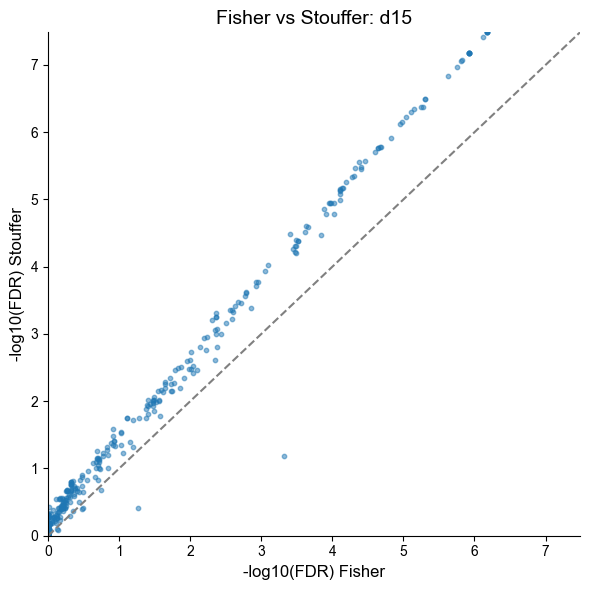

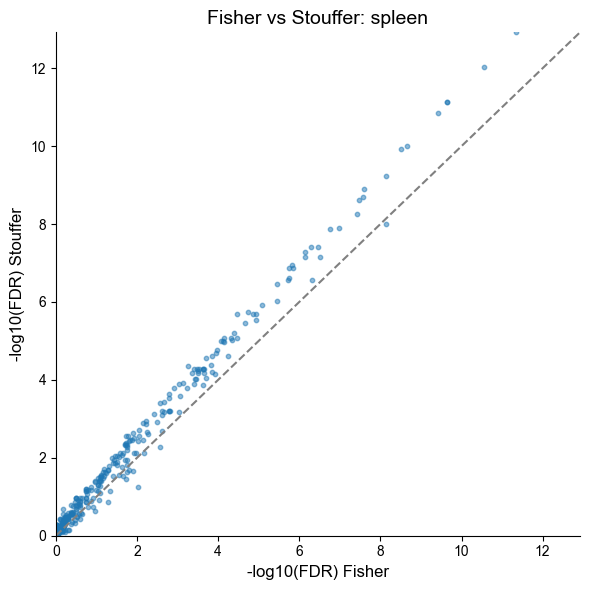

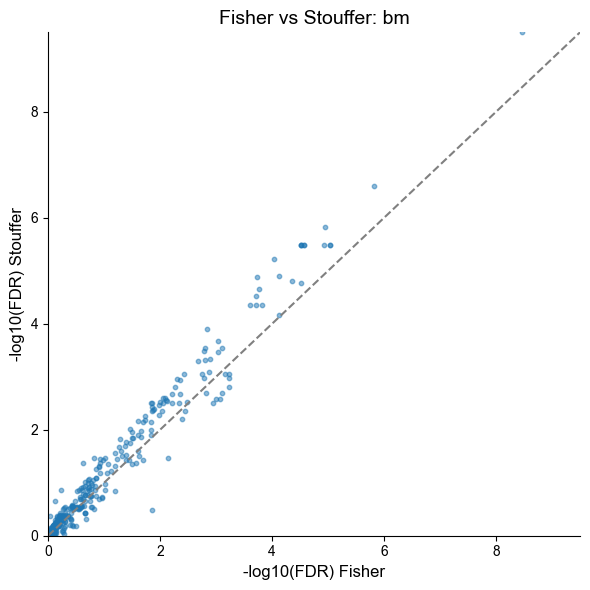

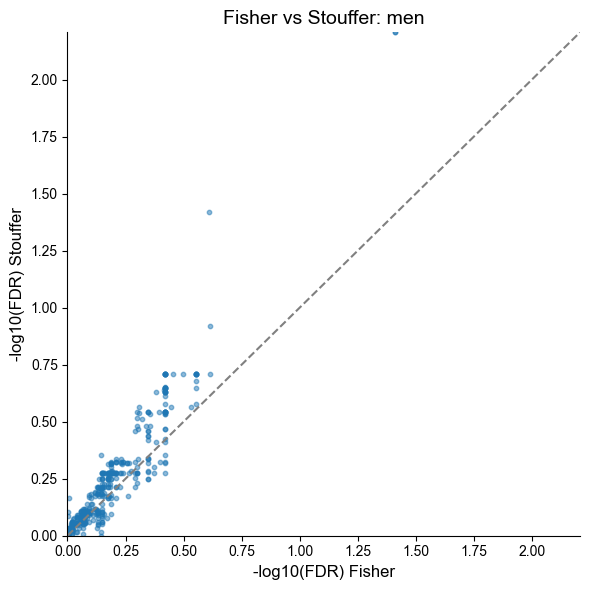

In [ ]:
conditions = ['d15', 'spleen', 'bm', 'men']
plot_fisher_vs_stouffer(combined_LFC_FDR_ABE, conditions)

In [ ]:
conditions = ['d15', 'spleen', 'bm', 'men']
plot_fisher_vs_stouffer(combined_LFC_FDR_ABE, conditions)